# Part 2 — Using KNN to classify new customers

In the previous notebook, K-Means converted unlabeled data into initial segments. 
After human verification and labeling, we now have the 'customers_segmented.csv' file.

Now imagine tomorrow we get a new customer. We want to look at their spending patterns 
and quickly suggest an appropriate segment. KNN will find the historical customers 
most similar to them, and then cast votes to select the label.

## Notebook Workflow:
Data labeled by K-Means and humans 
→ Train/test split 
→ Choose appropriate KNN 
→ Check results 
→ Predict new customers.

# Why not use KNN from the beginning?

KNN is like asking the neighbors: "Which group do the people most similar to this person belong to?". 
To ask that question, the neighbors must already have labels available.

Initially, we had no labels, so K-Means was needed to discover the structure first. 
Only after humans confirm or fix the group names does KNN have data to learn from. 
Therefore, the two algorithms do not work as separate tasks:
- K-Means creates the starting point when there are no labels.
- Humans inject business meaning into the groups.
- KNN uses the approved labels to handle new customers.

The metrics in this section only show how well KNN mimics the handed-over labels; 
they do not prove that the segments are definitively correct for the business.

## **I. Libraries and Data**

In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, train_test_split
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("customers_segmented.csv")

FEATURES = [
    "Fresh", "Milk", "Grocery", "Frozen",
    "Detergents_Paper", "Delicassen"
]
TARGET = "segment_label"

print(f"Đã nhận {len(df)} khách hàng từ notebook K-Means.")
df[[*FEATURES, TARGET]].head()

Đã nhận 440 khách hàng từ notebook K-Means.


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,segment_label
0,12669,9656,7561,214,2674,1338,High & Diverse Spenders
1,7057,9810,9568,1762,3293,1776,High & Diverse Spenders
2,6353,8808,7684,2405,3516,7844,High & Diverse Spenders
3,13265,1196,4221,6404,507,1788,Traditional Food Buyers
4,22615,5410,7198,3915,1777,5185,High & Diverse Spenders


# **II. Checking the results handed over from K-Means**

Before learning, KNN checks whether the file contains all six spending columns and the 
'segment_label' column. This minor step helps catch export errors early and clearly, 
rather than letting the model run for a while only to throw an unreadable error message later.

The count table also shows which groups have many or few customers. If a group is too small, 
Accuracy might look artificially high even if the model completely ignores that minority group.




In [3]:
required_columns = set(FEATURES + [TARGET])
missing_columns = required_columns - set(df.columns)
assert not missing_columns, f"Thiếu cột: {missing_columns}"
assert df[FEATURES + [TARGET]].notna().all().all(), "Dữ liệu còn giá trị thiếu"
assert df[TARGET].nunique() >= 2, "Cần ít nhất hai phân khúc"

display(df[TARGET].value_counts().rename("customers").to_frame())

,customers
segment_label,
Traditional Food Buyers,212
High & Diverse Spenders,145
Grocery & Consumer Goods,83


# **III. Splitting data for learning and testing**

We reserve 20% of the customers as test data, acting like an exam that KNN has never seen 
during its learning phase. The remaining part is the train data.

The 'stratify' option keeps the proportion of segments nearly identical in both parts. 
The log transform and normalization steps are placed inside a Pipeline so that each learning 
step only uses information from the train set, avoiding accidentally "peeking at the answers" 
from the test set.

Afterward, GridSearchCV tests multiple options:
- How many neighbors should vote together?
- Should closer neighbors have a louder voice (higher weight)?
- Should the closeness be measured by Manhattan or Euclid distance?

We select the configuration with the best average Macro-F1 score across five train folds.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES], df[TARGET], test_size=0.2, random_state=42)

In [ ]:
# pipeline
knn_pipeline = Pipeline([
    ("log_transform", FunctionTransformer(np.log1p, feature_names_out= "one-to-one")), #To normal distribution
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# search
param_grid = {
    "knn__n_neighbors": list(range(3, 26, 2)),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],  # Manhattan or Euclid
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
search.fit(X_train, y_train)

print(f"Tham số tốt nhất: {search.best_params_}")
print(f"Macro-F1 CV tốt nhất: {search.best_score_:.3f}")

Tham số tốt nhất: {'knn__n_neighbors': 19, 'knn__p': 2, 'knn__weights': 'uniform'}
Macro-F1 CV tốt nhất: 0.907


# IV. How well does KNN perform on the test?

After selecting the best configuration, KNN is allowed to predict on the test set:
- **Accuracy** is the overall proportion of correctly predicted customers.
- **Precision** asks: out of the customers predicted to be in a group, how many actually have that label?
- **Recall** asks: out of the customers who actually have a label, how many did the model manage to find?
- **Macro-F1** balances Precision and Recall, giving equal weight to each group.

**The confusion matrix** shows which groups the model commonly confuses with each other. 
The rows represent the handed-over labels; the columns represent the KNN predictions.


In [6]:
# Best estimator & predict on best estimator
best_knn = search.best_estimator_
y_pred = best_knn.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Macro-F1: {f1_score(y_test, y_pred, average='macro'):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

Accuracy: 0.966
Macro-F1: 0.959

Classification report:
                          precision    recall  f1-score   support

Grocery & Consumer Goods      1.000     0.882     0.938        17
 High & Diverse Spenders      0.963     0.963     0.963        27
 Traditional Food Buyers      0.957     1.000     0.978        44

                accuracy                          0.966        88
               macro avg      0.973     0.948     0.959        88
            weighted avg      0.967     0.966     0.965        88



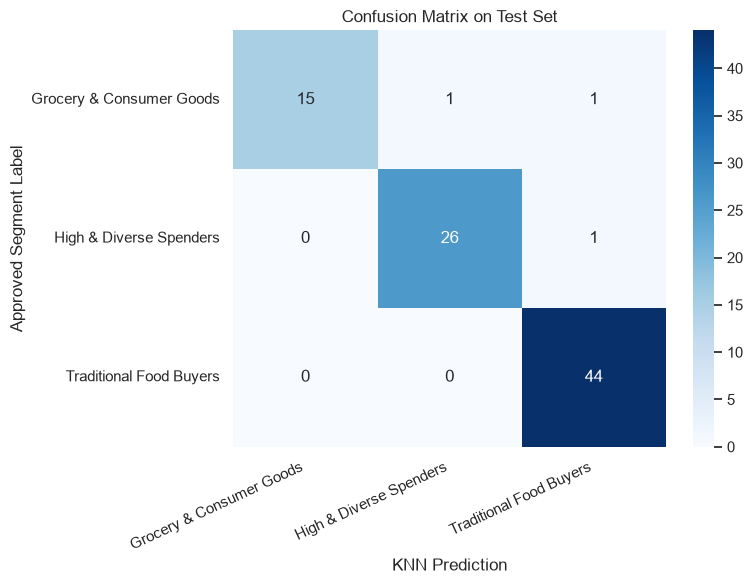

In [7]:
labels = sorted(df[TARGET].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels
)
# DỊCH TẠI ĐÂY: Chuyển các nhãn đồ thị sang tiếng Anh
plt.xlabel("KNN Prediction")
plt.ylabel("Approved Segment Label")
plt.title("Confusion Matrix on Test Set")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


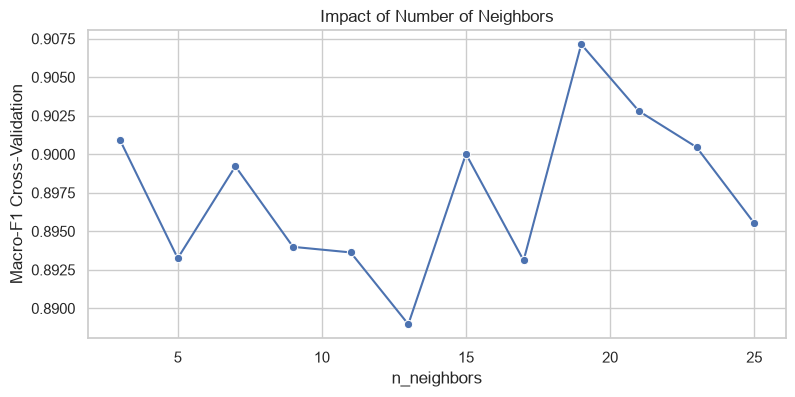

In [9]:
cv_results = pd.DataFrame(search.cv_results_)
curve = (
    cv_results.groupby("param_knn__n_neighbors", as_index=False)["mean_test_score"]
    .max()
    .rename(columns={
        "param_knn__n_neighbors": "n_neighbors",
        "mean_test_score": "best_macro_f1",
    })
)
plt.figure(figsize=(9, 4))
sns.lineplot(data=curve, x="n_neighbors", y="best_macro_f1", marker="o")
#
plt.title("Impact of Number of Neighbors")
plt.ylabel("Macro-F1 Cross-Validation")
plt.show()


# **V. When should we not trust predictions immediately?**

If 15 neighbors vote 15-0, the decision is quite clear. If the vote is 8-7, 
the customer lies in an overlapping and confusing region.

In this lesson, 'confidence' is the vote ratio of the winning group. This is 
a reference signal, not an absolute probability. Predictions with low confidence 
or whose neighbors are too far away should be escalated for human review.


In [10]:
neighbor_distances, neighbor_indices = best_knn.named_steps["knn"].kneighbors(
    best_knn[:-1].transform(X_test)
)
proba = best_knn.predict_proba(X_test)
confidence = proba.max(axis=1)

audit = X_test.copy()
audit["actual_segment"] = y_test
audit["predicted_segment"] = y_pred
audit["confidence"] = confidence
audit["mean_neighbor_distance"] = neighbor_distances.mean(axis=1)
audit["correct"] = audit["actual_segment"] == audit["predicted_segment"]

audit.sort_values(["confidence", "mean_neighbor_distance"]).head(10)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,actual_segment,predicted_segment,confidence,mean_neighbor_distance,correct
19,7780,2495,9464,669,2518,501,Grocery & Consumer Goods,High & Diverse Spenders,0.473684,1.103900,False
55,5264,3683,5005,1057,2024,1130,High & Diverse Spenders,High & Diverse Spenders,0.578947,0.947554,True
302,2886,5302,9785,364,6236,555,Grocery & Consumer Goods,Grocery & Consumer Goods,0.578947,1.155425,True
79,1640,3259,3655,868,1202,1653,Grocery & Consumer Goods,Traditional Food Buyers,0.578947,1.203819,False
155,1989,10690,19460,233,11577,2153,Grocery & Consumer Goods,Grocery & Consumer Goods,0.578947,1.293528,True
33,29729,4786,7326,6130,361,1083,High & Diverse Spenders,High & Diverse Spenders,0.631579,1.070820,True
17,5876,6157,2933,839,370,4478,High & Diverse Spenders,Traditional Food Buyers,0.631579,1.402444,False
76,717,3587,6532,7530,529,894,Traditional Food Buyers,Traditional Food Buyers,0.631579,1.687698,True
25,16165,4230,7595,201,4003,57,Grocery & Consumer Goods,Grocery & Consumer Goods,0.631579,1.891312,True
176,45640,6958,6536,7368,1532,230,High & Diverse Spenders,High & Diverse Spenders,0.684211,1.702077,True


# **VI. Using the entire dataset to serve new customers**

Only after completing the evaluation do we retrain the best configuration on the entire approved dataset. Doing this helps the final model leverage every available example.

The last cell creates two simulated customers, predicts their segments, and displays the confidence. When you have real data, simply replace the numbers in new_customers while keeping the names and units of the six columns intact.


In [11]:
final_knn = search.best_estimator_.fit(df[FEATURES], df[TARGET])
joblib.dump(final_knn, "knn_segment_classifier.joblib")

print("Đã lưu mô hình: knn_segment_classifier.joblib")

Đã lưu mô hình: knn_segment_classifier.joblib


In [12]:
new_customers = pd.DataFrame([
    {
        "Fresh": 12000, "Milk": 8000, "Grocery": 10000,
        "Frozen": 2000, "Detergents_Paper": 3500, "Delicassen": 1800,
    },
    {
        "Fresh": 9000, "Milk": 1500, "Grocery": 2200,
        "Frozen": 2500, "Detergents_Paper": 300, "Delicassen": 700,
    },
], index=["New_Customer_01", "New_Customer_02"])

new_predictions = final_knn.predict(new_customers)
new_proba = final_knn.predict_proba(new_customers)
prediction_result = new_customers.copy()
prediction_result["predicted_segment"] = new_predictions
prediction_result["confidence"] = new_proba.max(axis=1)
prediction_result

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,predicted_segment,confidence
New_Customer_01,12000,8000,10000,2000,3500,1800,High & Diverse Spenders,1.0
New_Customer_02,9000,1500,2200,2500,300,700,Traditional Food Buyers,1.0


## **Conclusion**

1. We start with unlabeled customer data.
2. K-Means finds groups with similar spending patterns.
3. Humans review cluster profiles, name them, and check borderline cases.
4. KNN learns from these handed-over labels.
5. When a new customer arrives, KNN looks at the nearest customers to suggest a group.

Both algorithms are distance-based, but the letter 'k' carries different meanings: 
in K-Means, 'k' is the number of clusters; in KNN, 'k' is the number of voting neighbors.

If an expert has not yet verified the data, consider the results as pseudo-labels. 
High accuracy at this stage only means that KNN has successfully learned how to replicate 
the clustering logic; it does not guarantee that the business strategy based on these groups 
will succeed.
